<a href="https://colab.research.google.com/github/naray130/ME-239-HW/blob/main/lecture04/homework_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture04:homework)=
# Homework 4

## Instructions

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name: Dhyan**
+ **Last Name: Narayanan**
+ **Email: naray130@purdue.edu**

Let me set you up with some nice code for plotting and downloading files.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')

/tmp/ipython-input-367591302.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Visual analysis of a variable-speed compressor experiment

In this problem you are going to need [this](https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-297-intro-to-data-science/master/data/compressor_data.xlsx) dataset. The dataset was kindly provided to us by [Professor Davide Ziviani](https://scholar.google.com/citations?user=gPdAtg0AAAAJ&hl=en).
As before, you can either put it on your Google drive or just download it with the code segment below:

In [2]:
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/compressor_data.xlsx'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14771  100 14771    0     0  90485      0 --:--:-- --:--:-- --:--:-- 90619


The data are part of a an experimental study of a variable speed reciprocating compressor.
The experimentalists varied two temperatures $T_e$ and $T_c$ (both in degrees C) and they measured various other quantities.
Your goal is to understand the experimental design and develop some intuition of the map between $T_e$ and $T_c$ and measured Capacity and Power (both in W).
Answer the following questions.

+ Do the scatter plot of $T_e$ and $T_c$. This will reveal the experimental design picked by the experimentalists. Make sure you label the axes correctly. Hint: These are columns `T_e` and `T_c` of the data frame `data`.

Text(0, 0.5, '$T_c$')

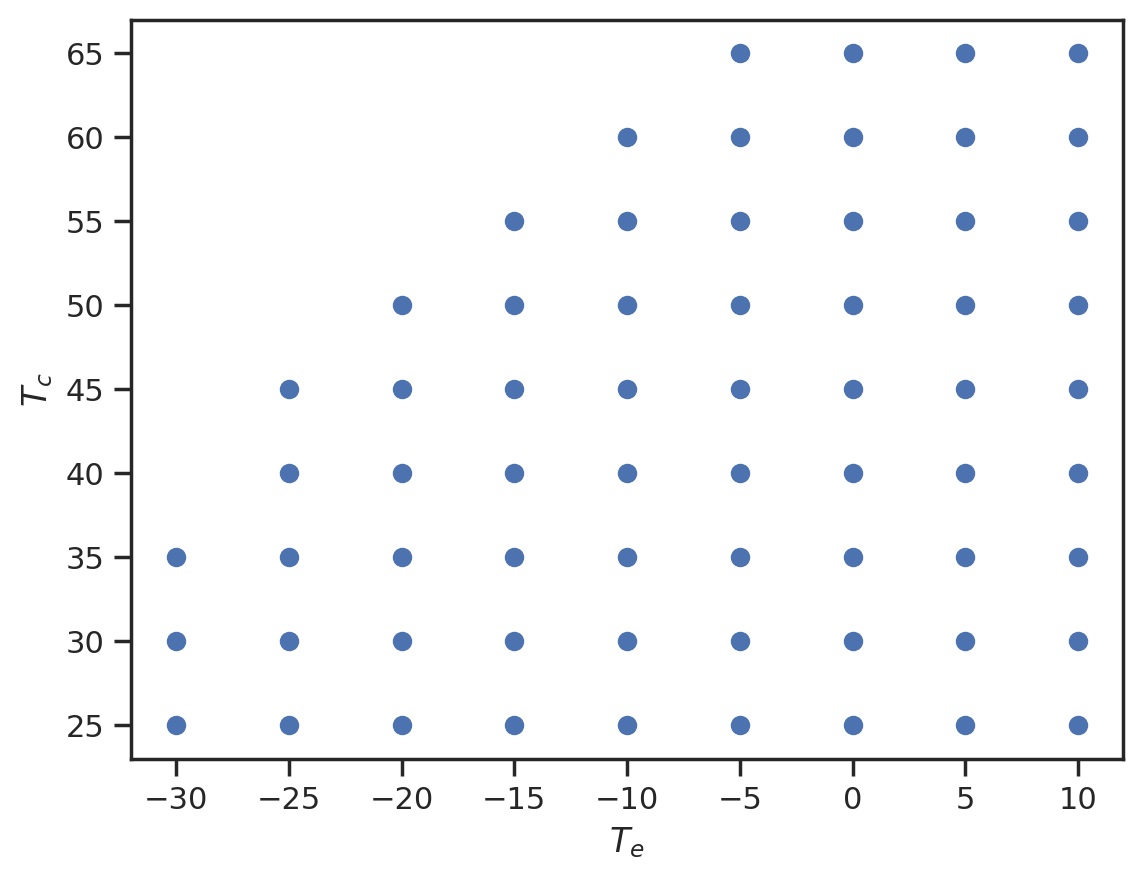

In [3]:
# your code here
import pandas as pd
data = pd.read_excel('compressor_data.xlsx')

t_e = data['T_e']
t_c = data['T_c']

plt.scatter(t_e, t_c)
plt.xlabel('$T_e$')
plt.ylabel('$T_c$')

+ Is there a gap in the experimental design? If yes, why do you think they have a gap?

Yes there is a gap in the experimental design. The gap is that there are no experimental values when there are low $T_e$ values and high $T_c$ values. I think there is a gap in the experment in this region as it may be hard to measure values at high $T_c$ values. I believe that it becomes harder to measure the $T_c$ and $T_e$ when they are greatly different from each other.

+ Do the scatter plot between `T_e` and `Capacity`.

Text(0, 0.5, 'Capacity [W]')

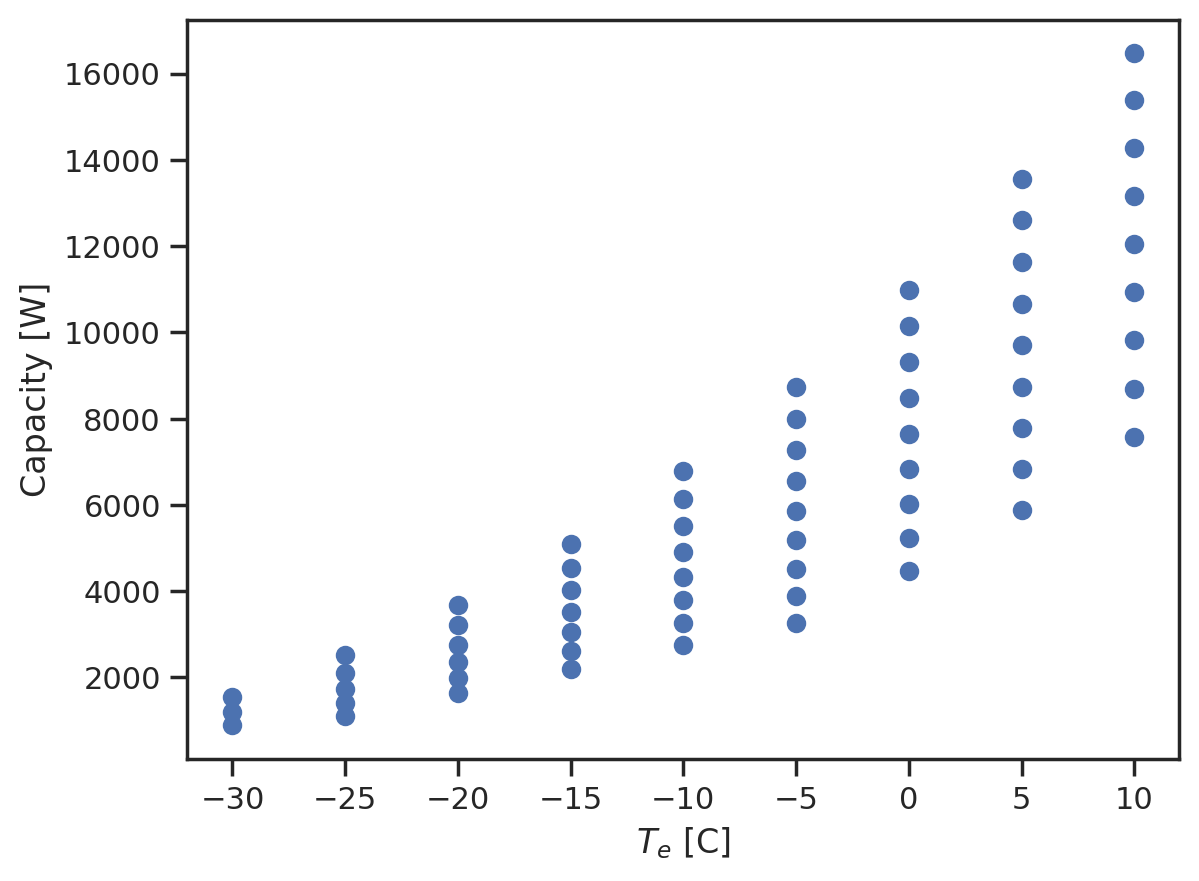

In [4]:
# your code here

capacity = data['Capacity']
plt.scatter(t_e, capacity)
plt.xlabel('$T_e$ [C]')
plt.ylabel('Capacity [W]')

+ Do the scatter plot between `T_c` and `Capacity`.

Text(0, 0.5, 'Capacity [W]')

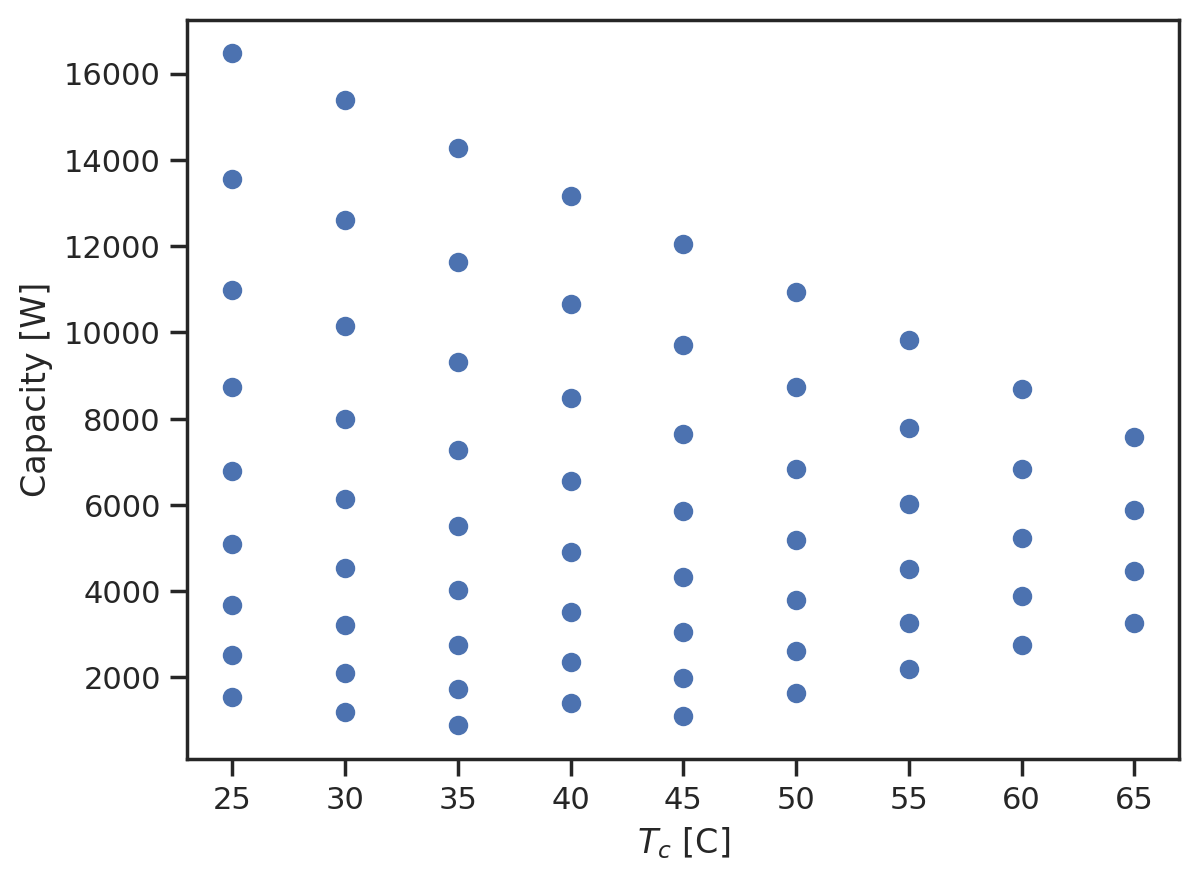

In [5]:
# your code here
plt.scatter(t_c, capacity)
plt.xlabel('$T_c$ [C]')
plt.ylabel('Capacity [W]')


+ Do the scatter plot between `T_e` and `Power`.

Text(0, 0.5, 'Power [W]')

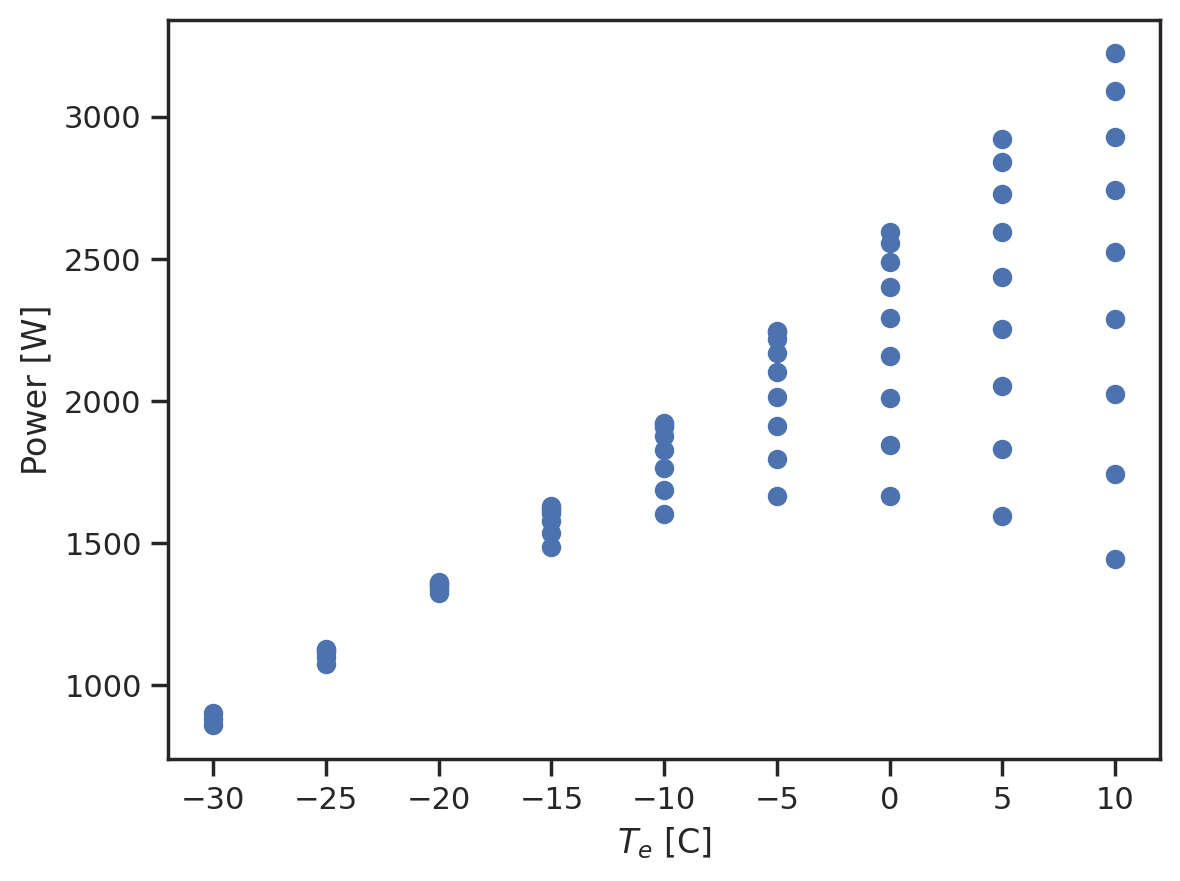

In [6]:
# your code here

power = data['Power']
plt.scatter(t_e, power)

plt.xlabel('$T_e$ [C]')
plt.ylabel('Power [W]')



+ Do the scatter plot between `T_c` and `Power`.

Text(0, 0.5, 'Power [W]')

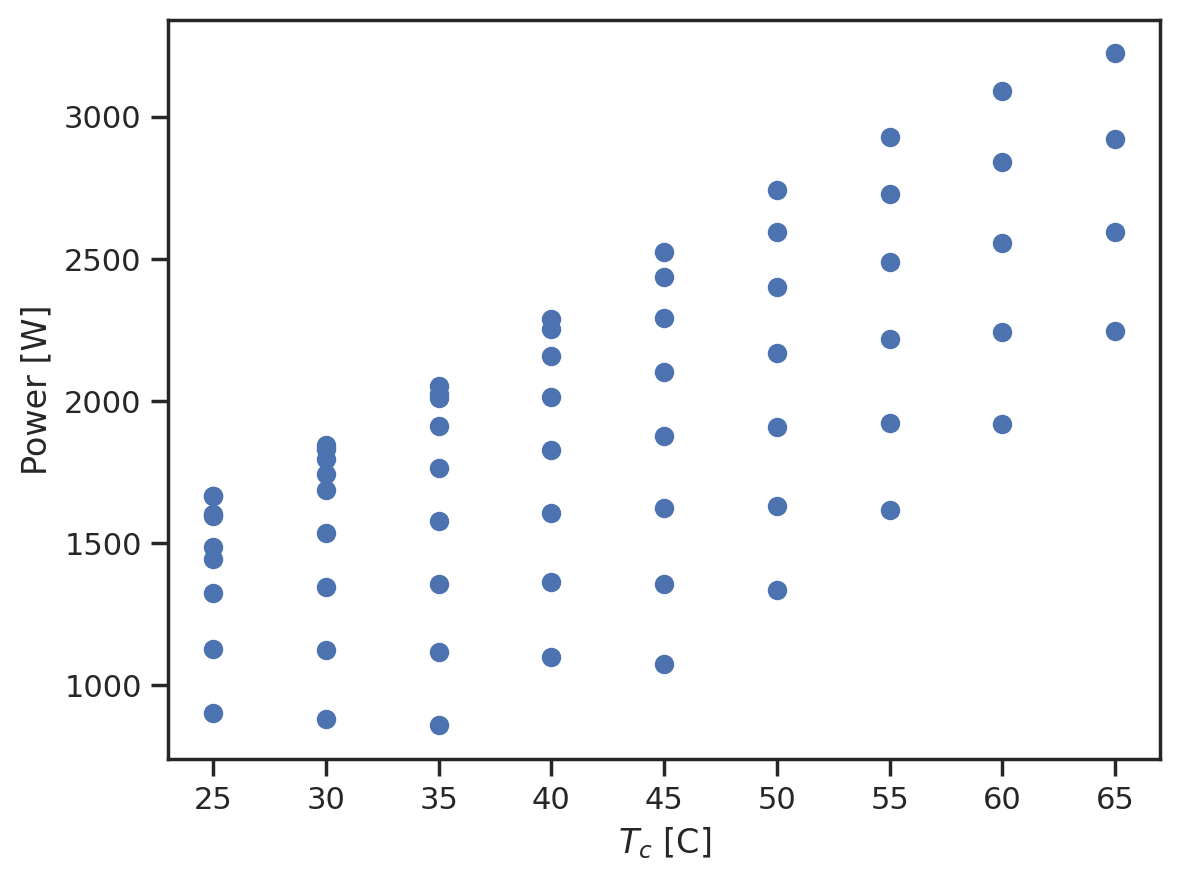

In [7]:
# your code here

plt.scatter(t_c, power)

plt.xlabel('$T_c$ [C]')
plt.ylabel('Power [W]')

+ We are lucky that we only have two experimental control variables because can do a bit more thing with scatter. You can color each point in the scatter plot according to a scale that follows an output variable. Let me show you what I mean by doing the plot for the `Capacity`.

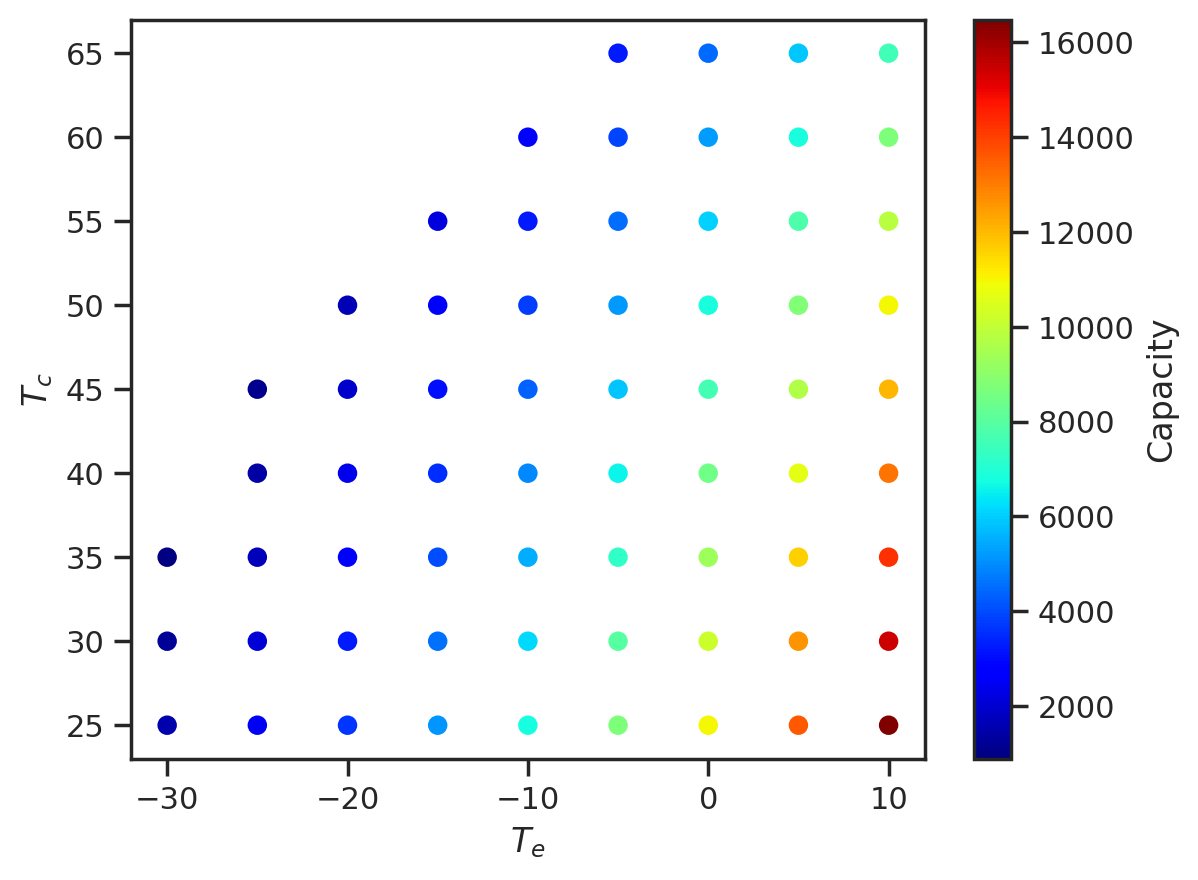

In [8]:
from matplotlib import cm
fig, ax = plt.subplots()
cs = ax.scatter(data['T_e'], data['T_c'], # So far a standard scatter plot
                c=data['Capacity'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Capacity')   # This gives us a colorbar
ax.set_xlabel('$T_e$')
ax.set_ylabel('$T_c$');

Now repeat the same thing for the `Power`:

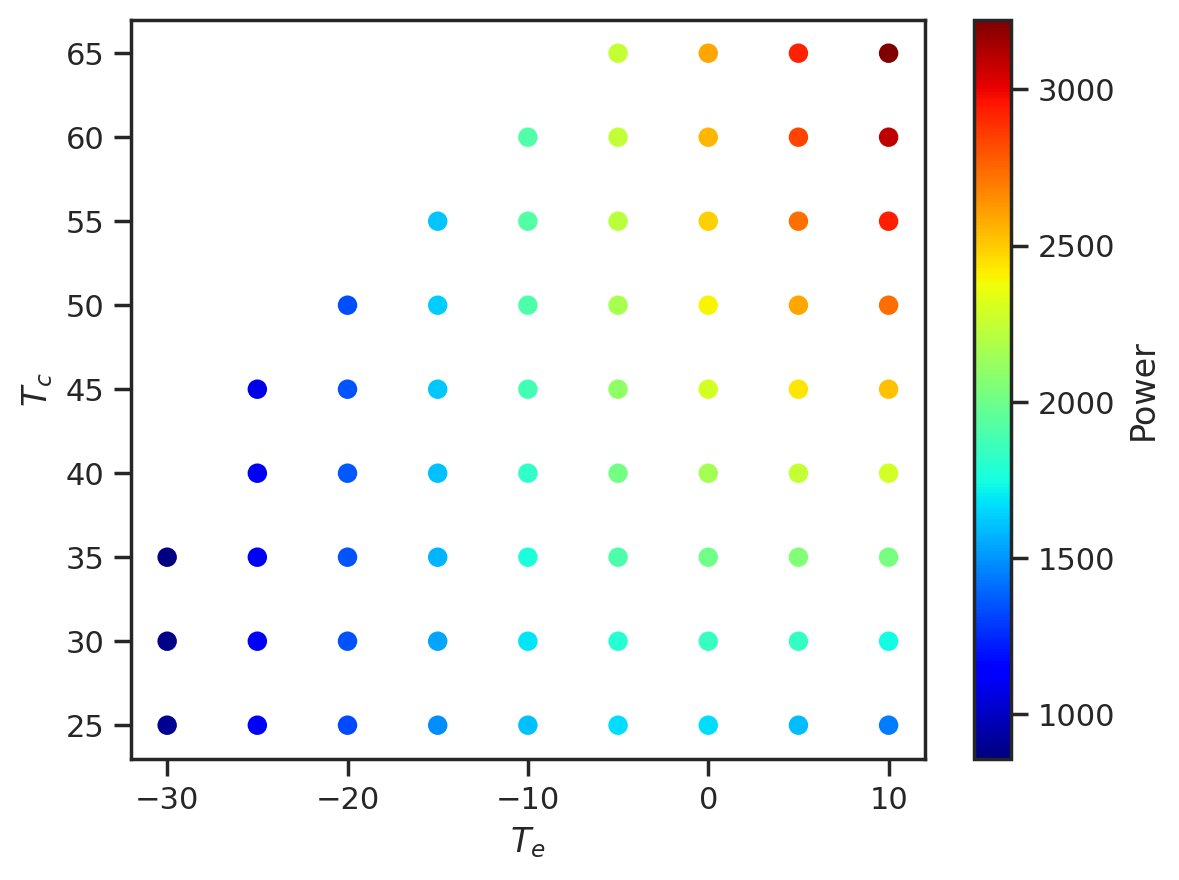

In [9]:
# your code here

from matplotlib import cm
fig, ax = plt.subplots()
cs = ax.scatter(data['T_e'], data['T_c'], # So far a standard scatter plot
                c=data['Power'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Power')   # This gives us a colorbar
ax.set_xlabel('$T_e$')
ax.set_ylabel('$T_c$');

## Problem 2 - Visual analysis of an airfoil experiment

In this problem, you are going to repeat what you did in Problem 1, but without my guidance!

The dataset we are going to use is the [Airfoil Self-Noise Data Set](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise)
From this reference, the descreption of the dataset is as follows:

> The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel speeds and angles of attack. The span of the airfoil and the observer position were the same in all of the experiments.
>
> Attribute Information:
> This problem has the following inputs:
> 1. Frequency, in Hertzs.
> 2. Angle of attack, in degrees.
> 3. Chord length, in meters.
> 4. Free-stream velocity, in meters per second.
> 5. Suction side displacement thickness, in meters.

> The only output is:
> 6. Scaled sound pressure level, in decibels.

Before we start, let's download and load the data.
I am going to put them in a dataframe for you.

In [10]:
!curl -O 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
import numpy as np
import pandas as pd
raw_data = np.loadtxt('airfoil_self_noise.dat')
df = pd.DataFrame(raw_data,
                  columns=['Frequency', 'Angle_of_attack', 'Chord_length',
                            'Velocity', 'Suction_thickness', 'Sound_pressure'])
df

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 59984    0 59984    0     0   158k      0 --:--:-- --:--:-- --:--:--  158k


,Frequency,Angle_of_attack,Chord_length,Velocity,Suction_thickness,Sound_pressure
0,800.0,0.0,0.3048,71.3,0.002663,126.201
1,1000.0,0.0,0.3048,71.3,0.002663,125.201
2,1250.0,0.0,0.3048,71.3,0.002663,125.951
3,1600.0,0.0,0.3048,71.3,0.002663,127.591
4,2000.0,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500.0,15.6,0.1016,39.6,0.052849,110.264
1499,3150.0,15.6,0.1016,39.6,0.052849,109.254
1500,4000.0,15.6,0.1016,39.6,0.052849,106.604
1501,5000.0,15.6,0.1016,39.6,0.052849,106.224


+ Do the histogtrams of all variables. Use as many code segments you need below to plot the histogram of each variable in a different plot. Make sure you label the axes correctly.

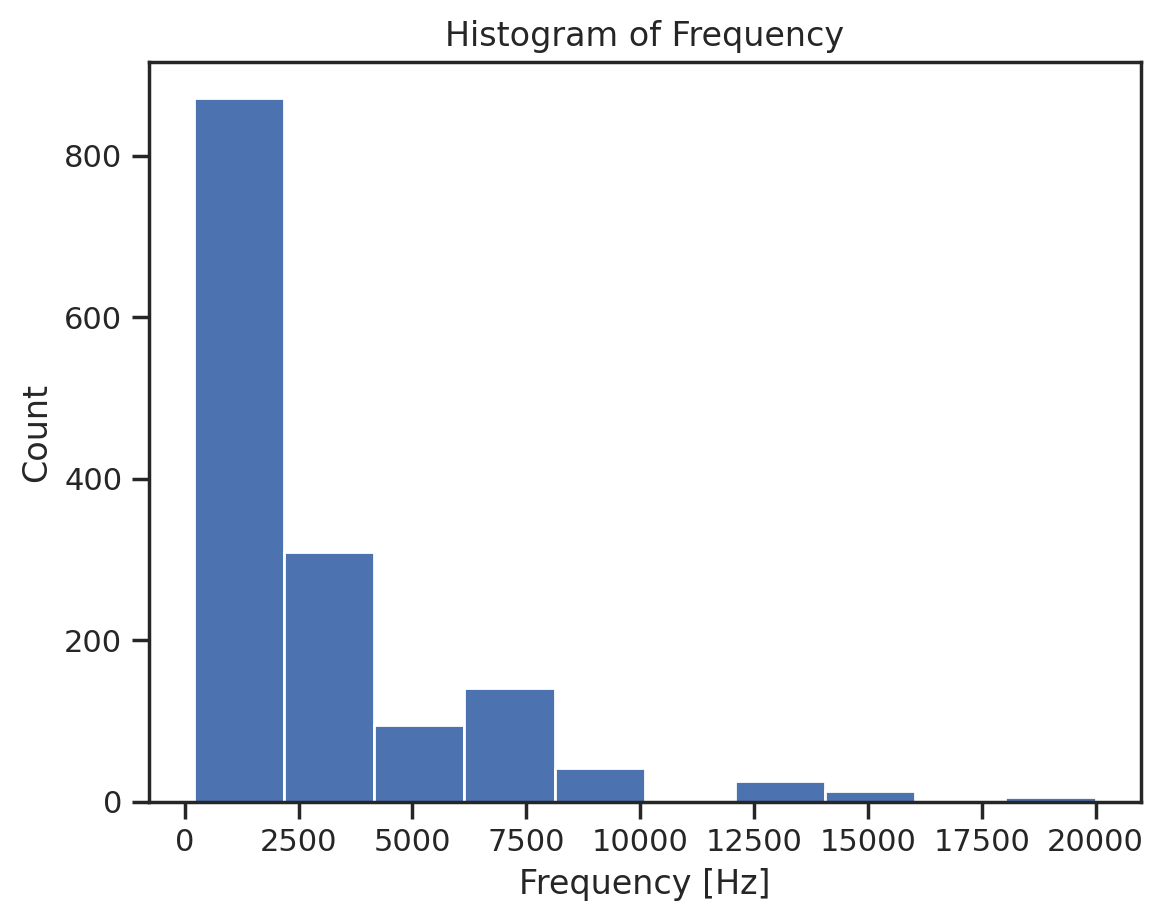

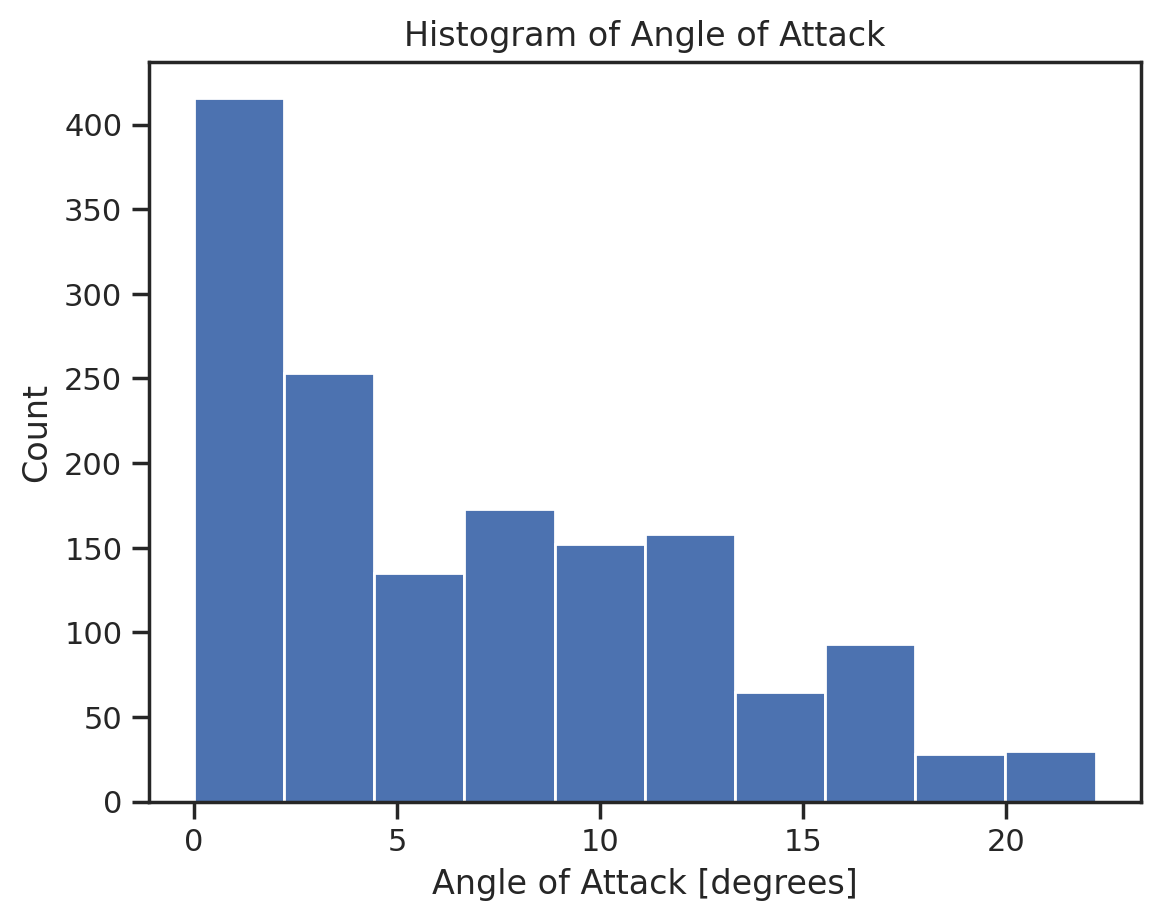

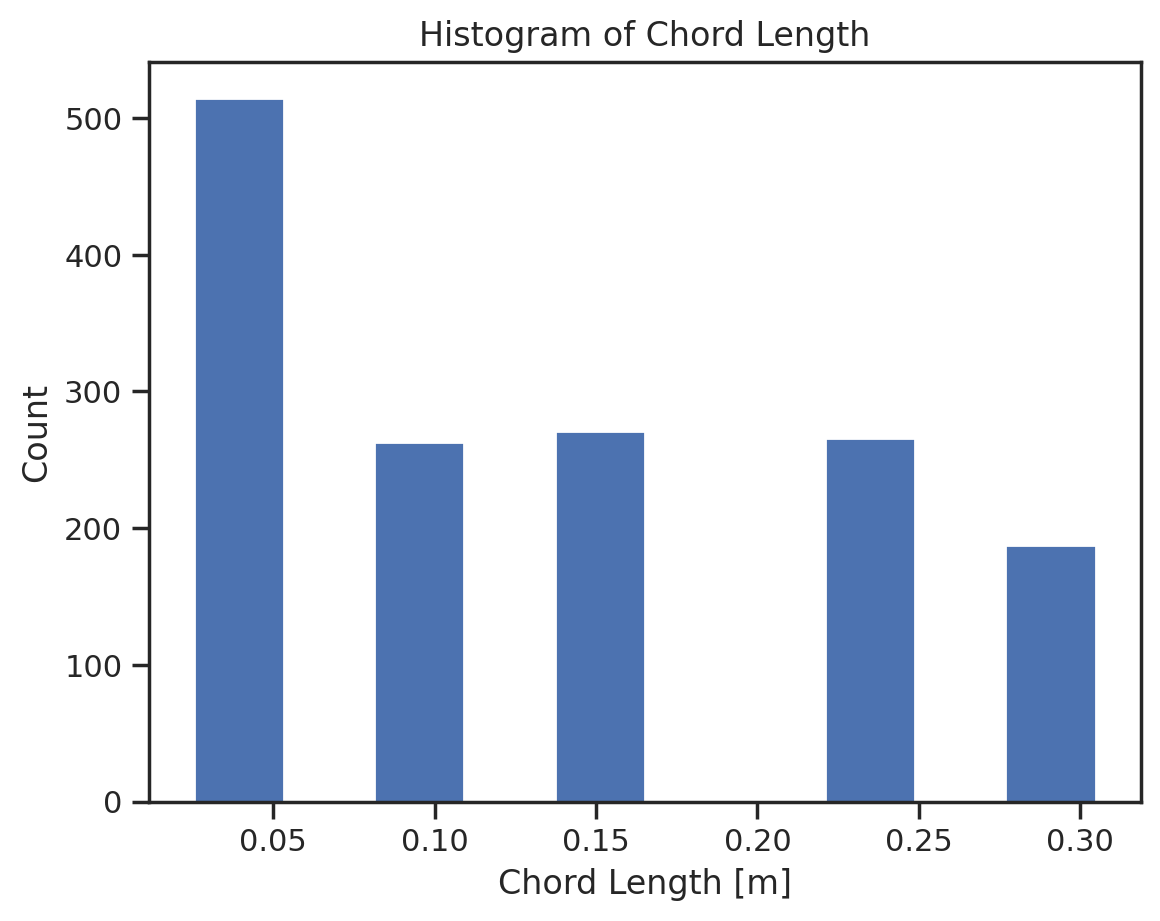

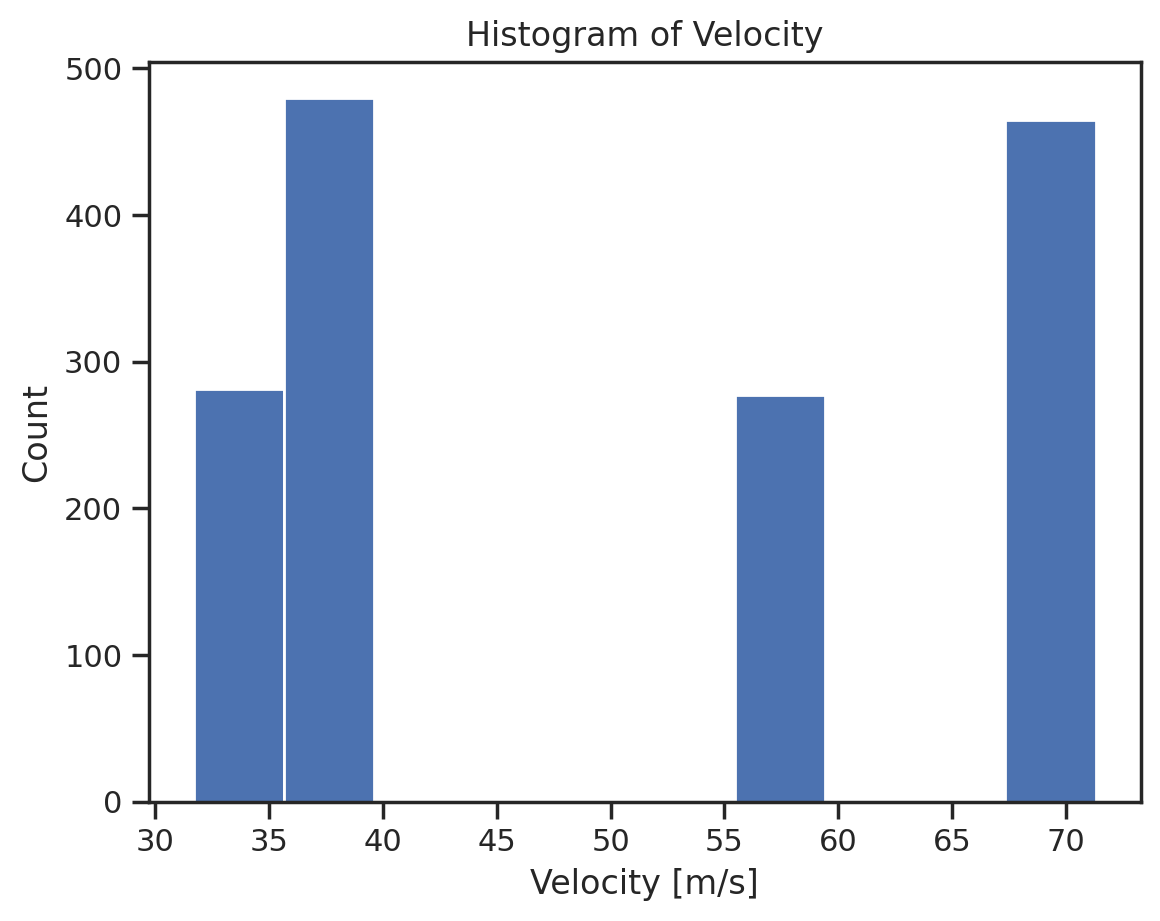

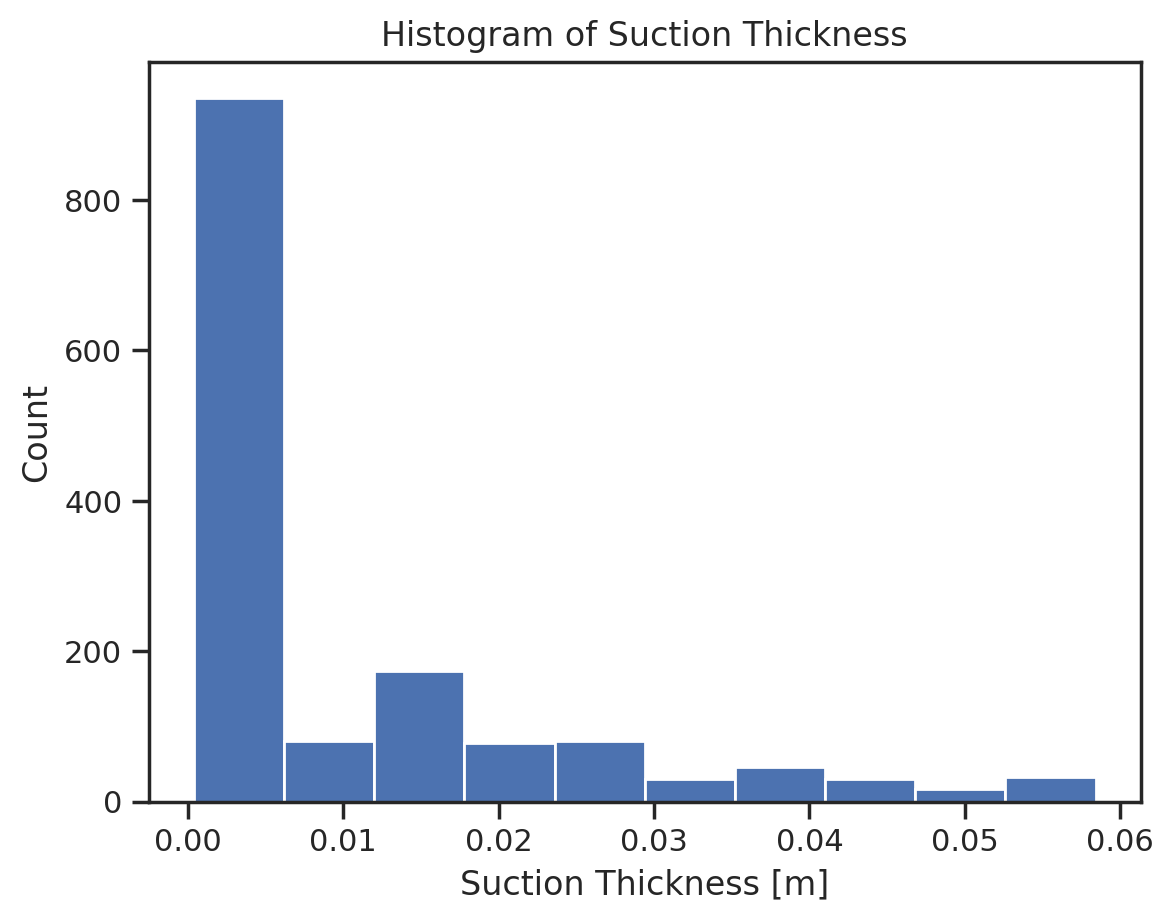

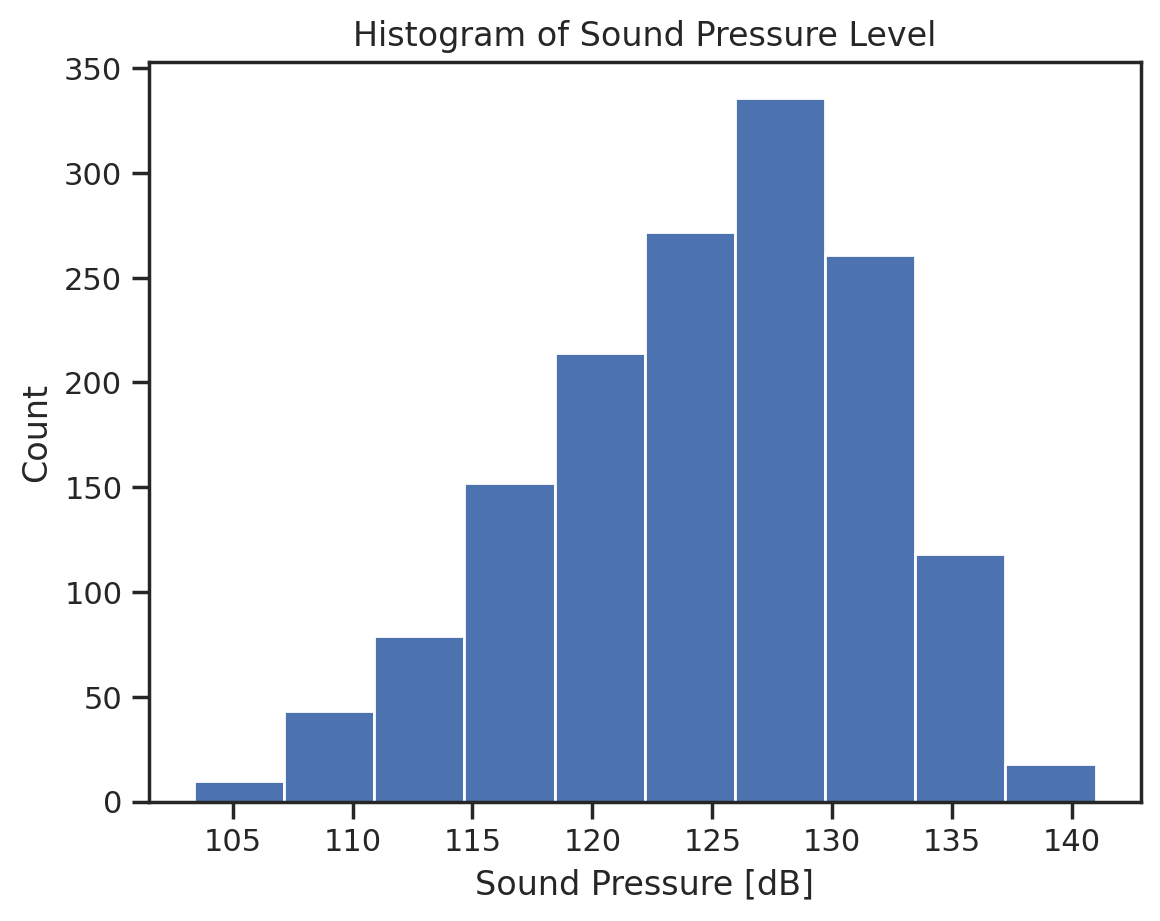

In [11]:
# your code here (as many blocks as you like)

import matplotlib.pyplot as plt

#Frequency Histogram
plt.hist(df['Frequency'])
plt.title('Histogram of Frequency')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Count')
plt.show()

#AoA Histogram
plt.hist(df['Angle_of_attack'])
plt.title('Histogram of Angle of Attack')
plt.xlabel('Angle of Attack [degrees]')
plt.ylabel('Count')
plt.show()

#Chord Length Histogram
plt.hist(df['Chord_length'])
plt.title('Histogram of Chord Length')
plt.xlabel('Chord Length [m]')
plt.ylabel('Count')
plt.show()

#Velocity Histogram
plt.hist(df['Velocity'])
plt.title('Histogram of Velocity')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Count')
plt.show()

#Suction Thickness Histogram
plt.hist(df['Suction_thickness'])
plt.title('Histogram of Suction Thickness')
plt.xlabel('Suction Thickness [m]')
plt.ylabel('Count')
plt.show()

#Sound Pressure Histogram
plt.hist(df['Sound_pressure'])
plt.title('Histogram of Sound Pressure Level')
plt.xlabel('Sound Pressure [dB]')
plt.ylabel('Count')
plt.show()

+ Do the scatter plot between all input variables. This will give you an idea of the range of experimental conditions. Are there any holes in the experimental dataset, i.e., places where you have no data?

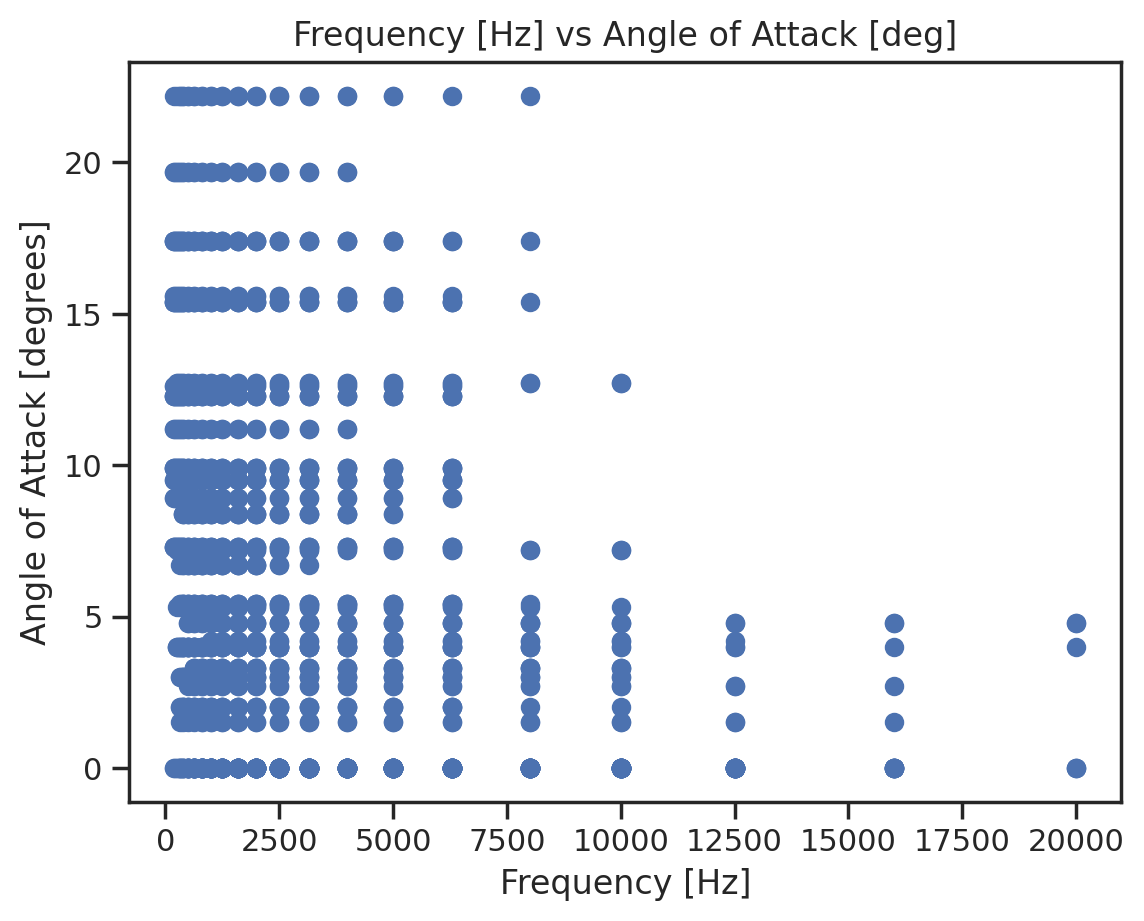

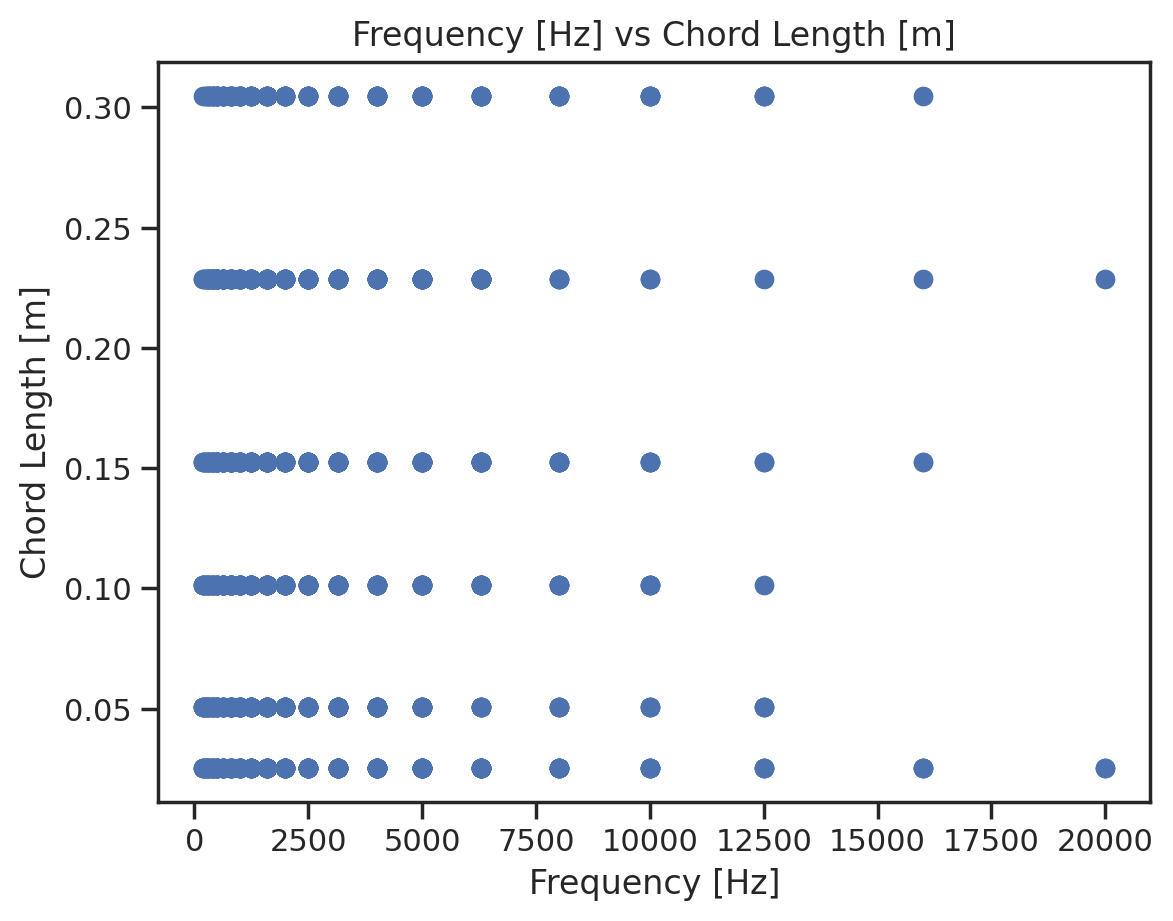

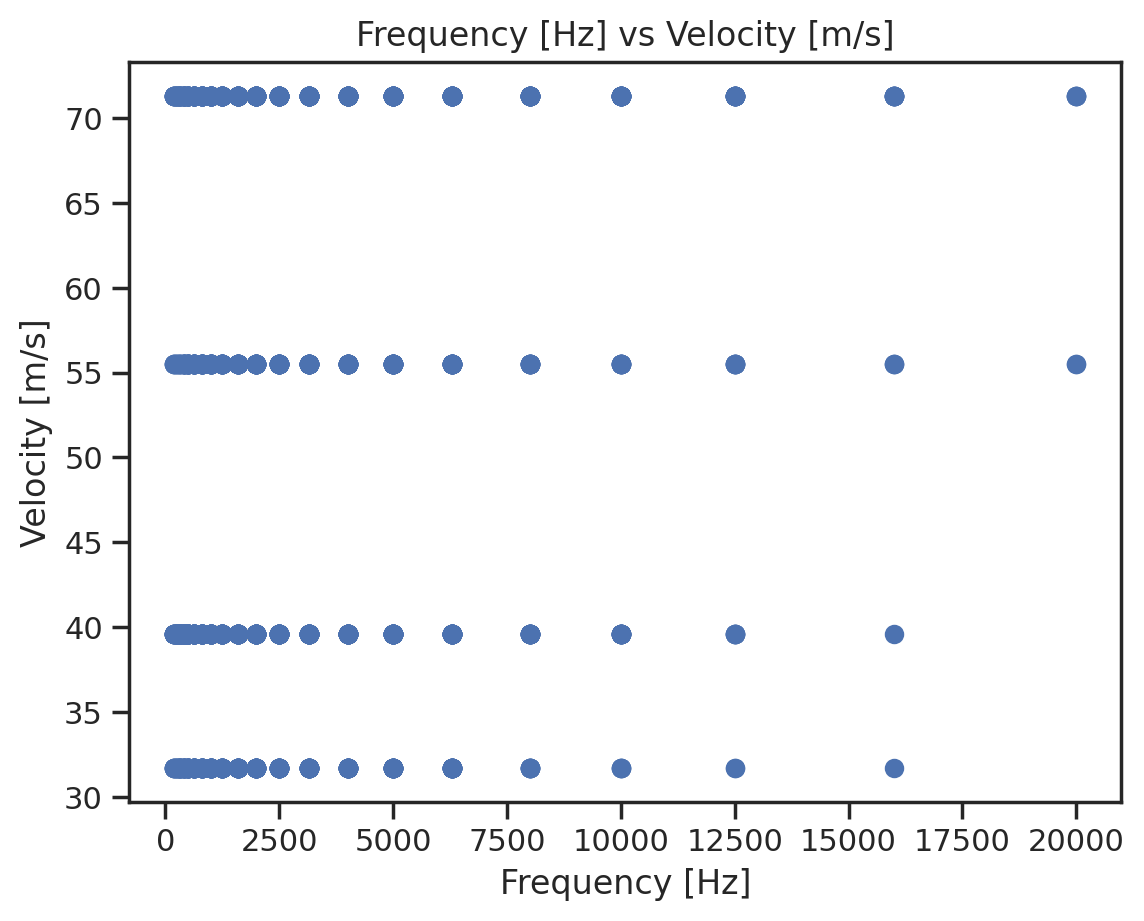

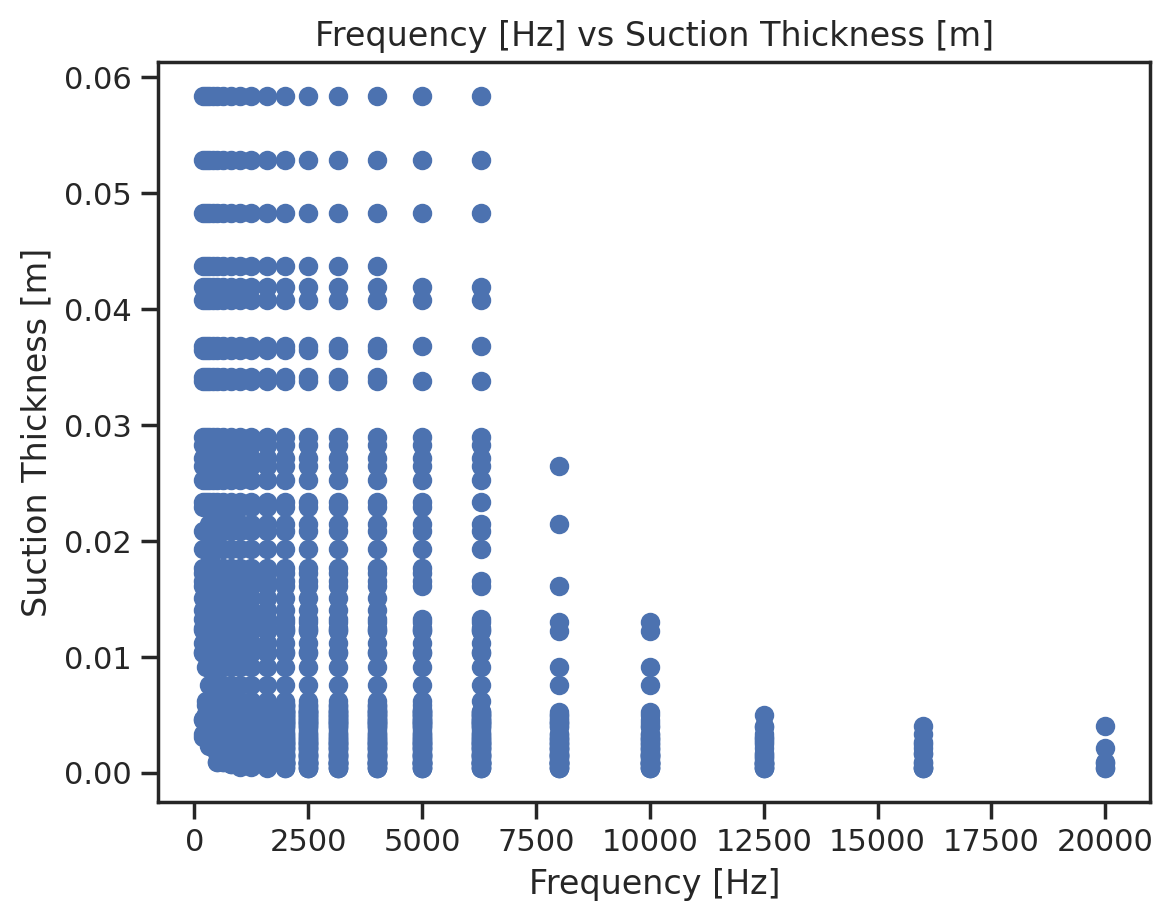

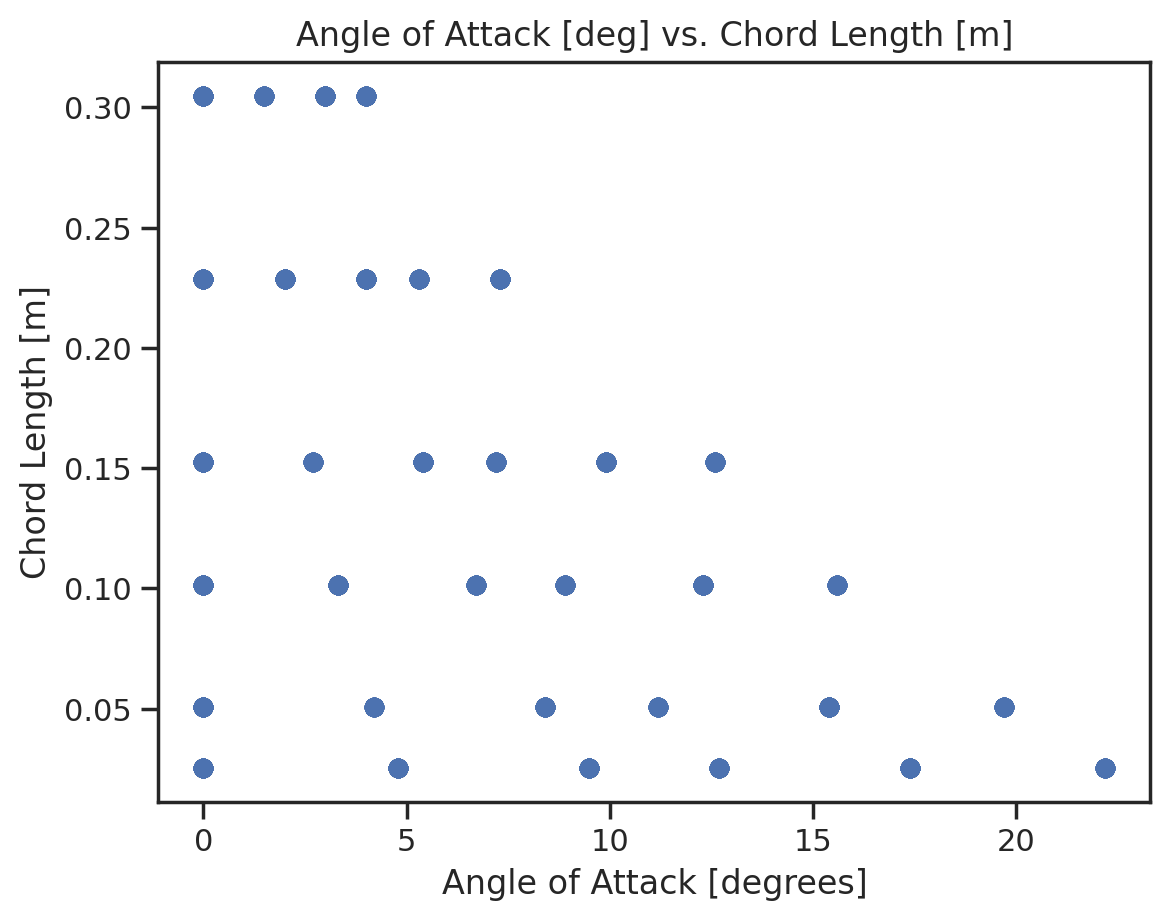

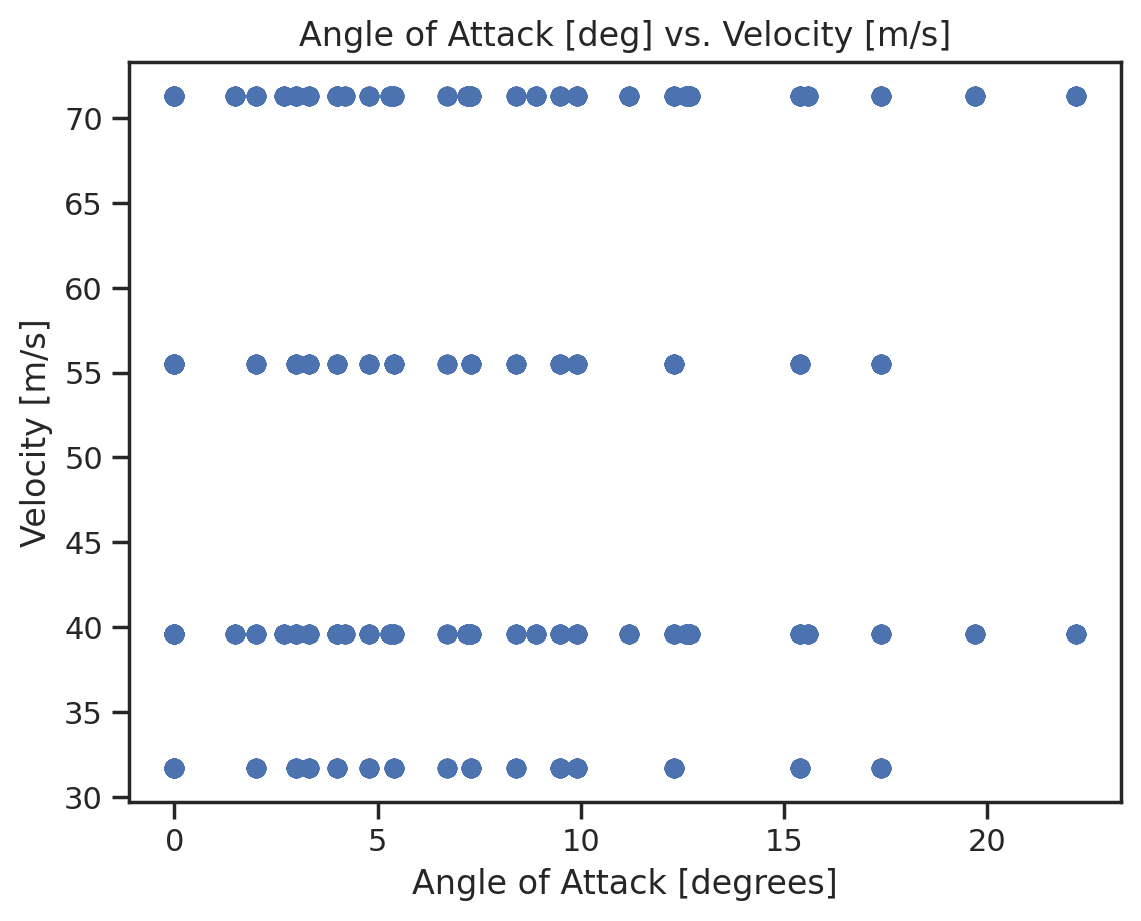

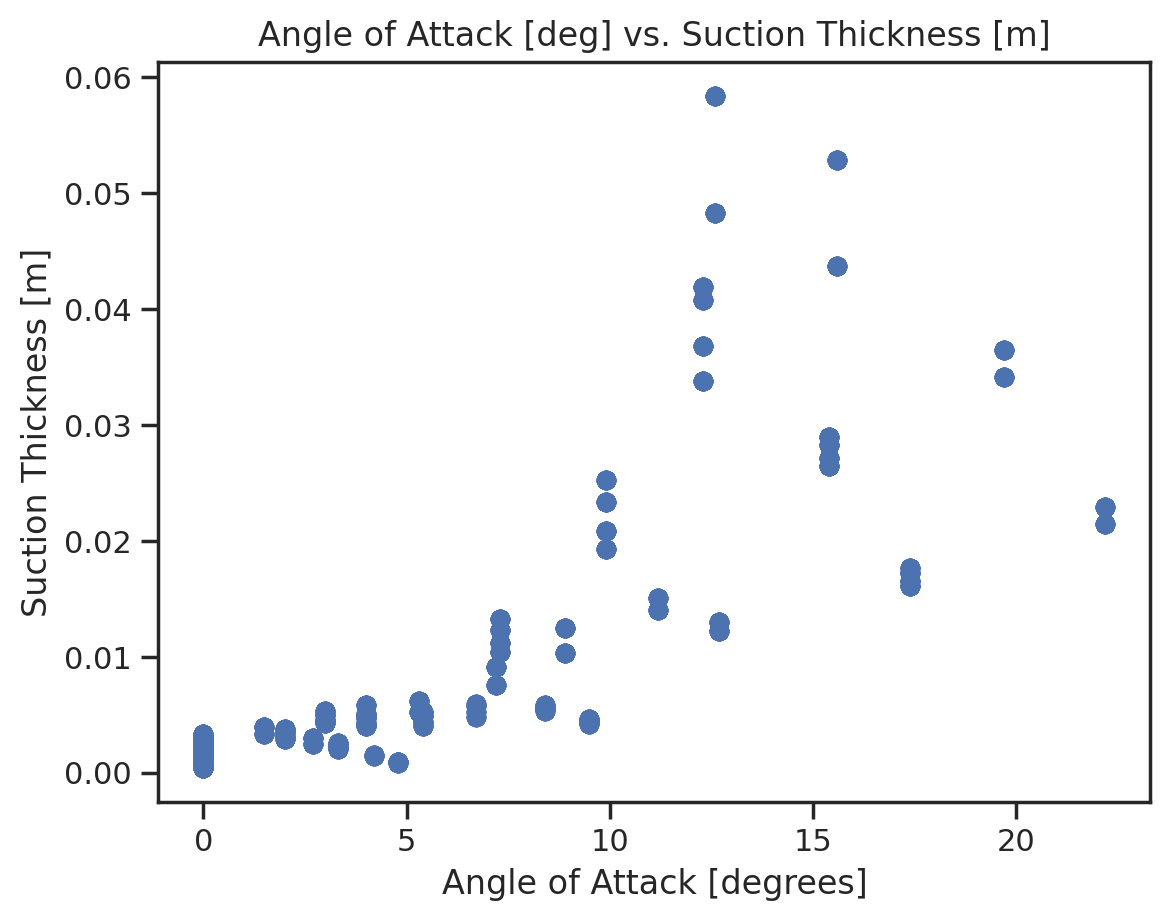

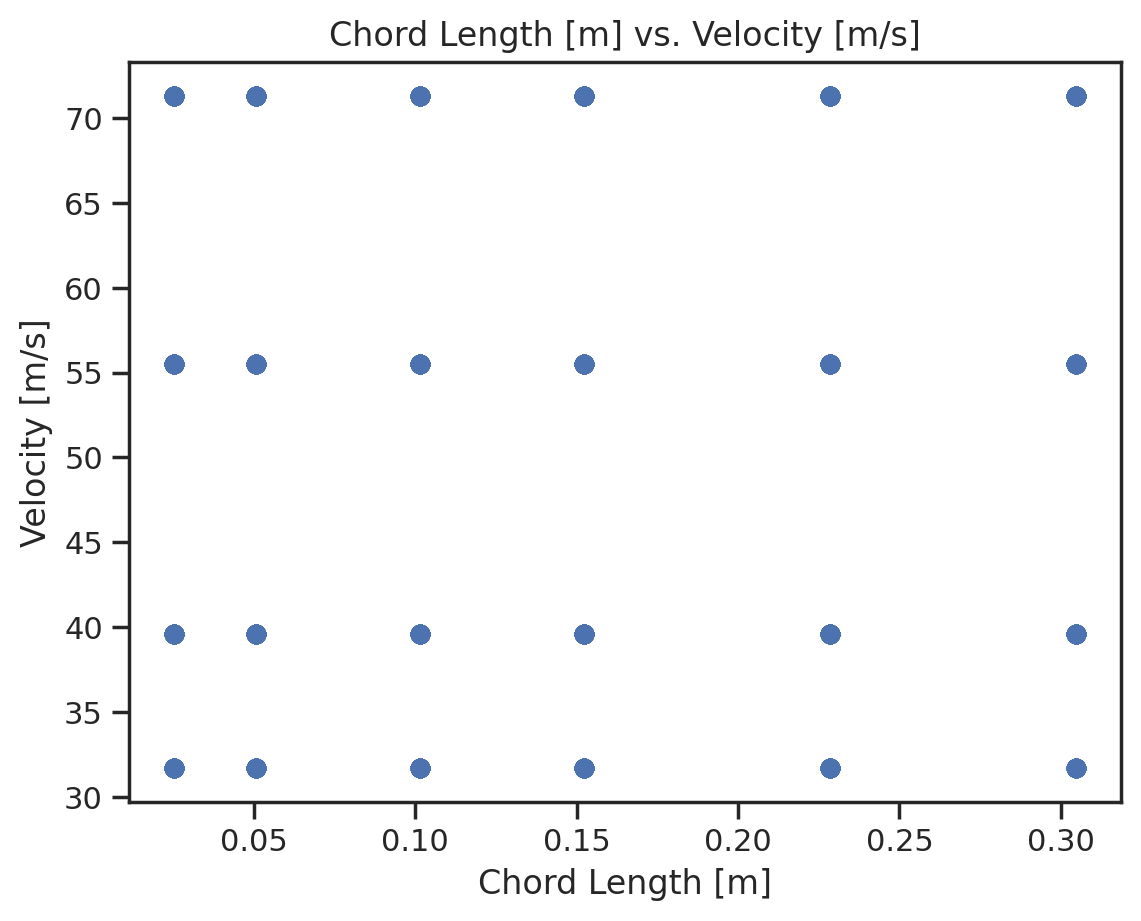

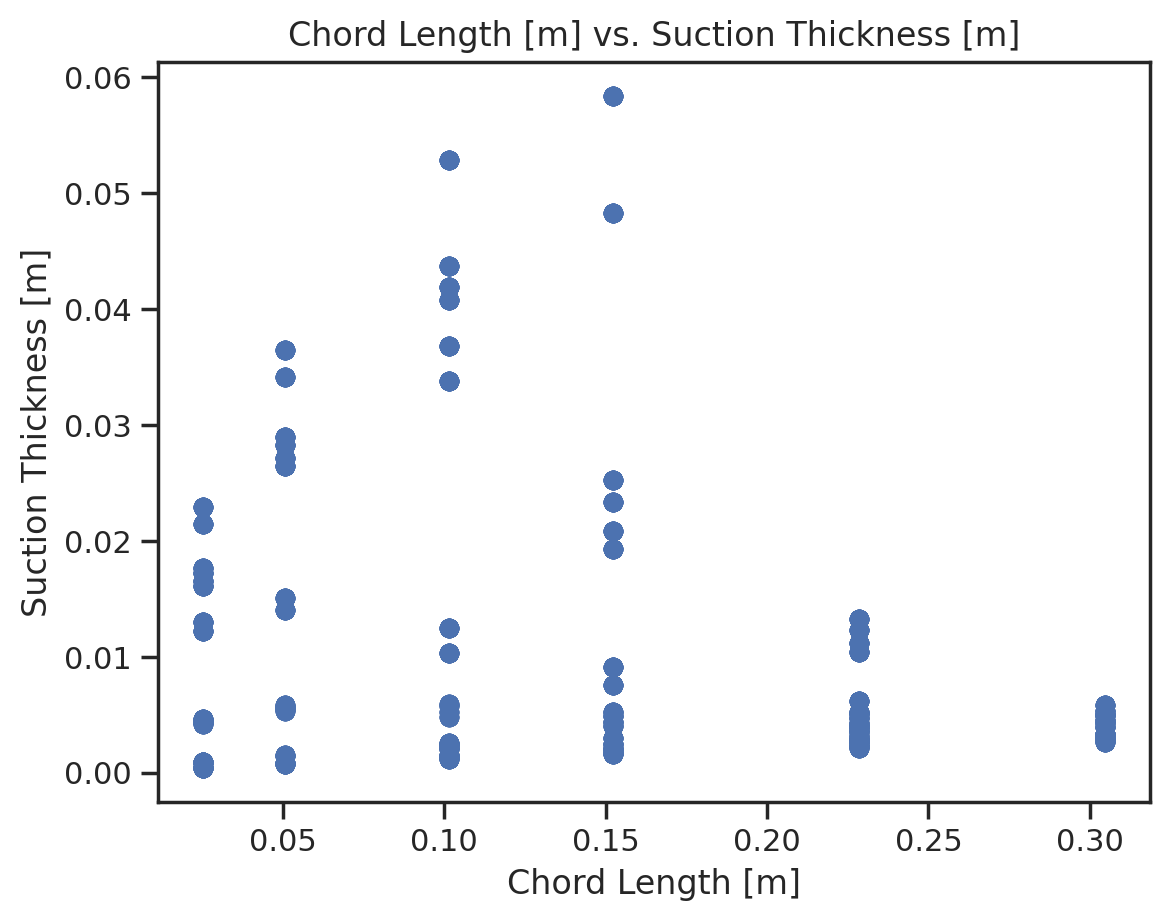

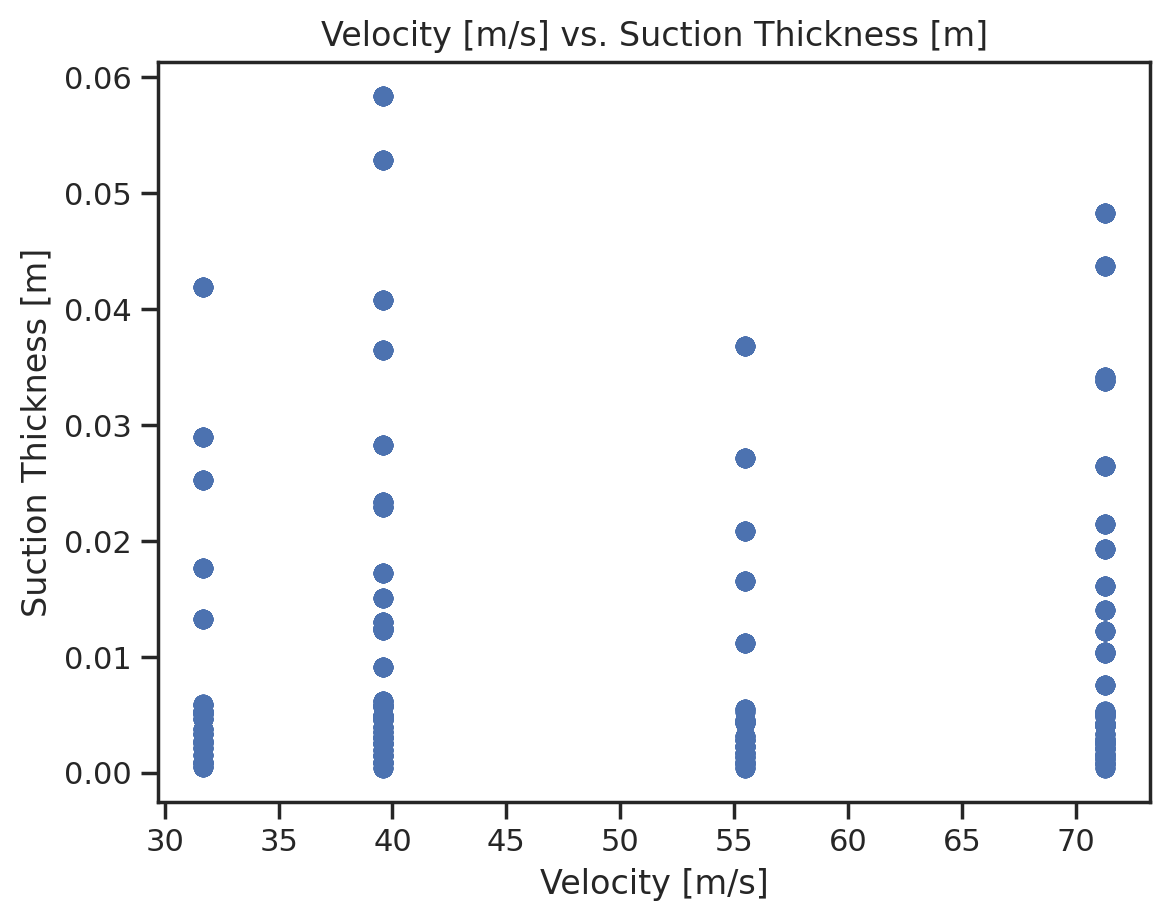

In [12]:
# your code here (as many blocks as you like)

import matplotlib.pyplot as plt

plt.scatter(df['Frequency'], df['Angle_of_attack'])
plt.title('Frequency [Hz] vs Angle of Attack [deg]')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Angle of Attack [degrees]')
plt.show()


plt.scatter(df['Frequency'], df['Chord_length'])
plt.title('Frequency [Hz] vs Chord Length [m]')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Chord Length [m]')
plt.show()

plt.scatter(df['Frequency'], df['Velocity'])
plt.title('Frequency [Hz] vs Velocity [m/s]')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity [m/s]')
plt.show()

plt.scatter(df['Frequency'], df['Suction_thickness'])
plt.title('Frequency [Hz] vs Suction Thickness [m]')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Suction Thickness [m]')
plt.show()

plt.scatter(df['Angle_of_attack'], df['Chord_length'])
plt.title('Angle of Attack [deg] vs. Chord Length [m]')
plt.xlabel('Angle of Attack [degrees]')
plt.ylabel('Chord Length [m]')
plt.show()

plt.scatter(df['Angle_of_attack'], df['Velocity'])
plt.title('Angle of Attack [deg] vs. Velocity [m/s]')
plt.xlabel('Angle of Attack [degrees]')
plt.ylabel('Velocity [m/s]')
plt.show()

plt.scatter(df['Angle_of_attack'], df['Suction_thickness'])
plt.title('Angle of Attack [deg] vs. Suction Thickness [m]')
plt.xlabel('Angle of Attack [degrees]')
plt.ylabel('Suction Thickness [m]')
plt.show()

plt.scatter(df['Chord_length'], df['Velocity'])
plt.title('Chord Length [m] vs. Velocity [m/s]')
plt.xlabel('Chord Length [m]')
plt.ylabel('Velocity [m/s]')
plt.show()

plt.scatter(df['Chord_length'], df['Suction_thickness'])
plt.title('Chord Length [m] vs. Suction Thickness [m]')
plt.xlabel('Chord Length [m]')
plt.ylabel('Suction Thickness [m]')
plt.show()

plt.scatter(df['Velocity'], df['Suction_thickness'])
plt.title('Velocity [m/s] vs. Suction Thickness [m]')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Suction Thickness [m]')
plt.show()



Yes there are holes in the experiment data, as certain independent variables such as velocity and chord length were only measured at integer values, meaning any value in between integer values (i.e. 45.5 m/s) is not recorded. Furthrmore, for the velocity, there were no values recorded between 40 and 50 m/s. Another gap that was present, was when there were low angles of attack along with high suction thickness values. There was also a gap in the experiment for the high AoA values and high chord length values. Lastly, there was a significant gap in the data related to the high frequencies and the greater suction thickness.

+  Do the scatter plot between each input variable and the output. This will give you an idea of the relationship between each input and the output. Do you observe any obvious patterns?

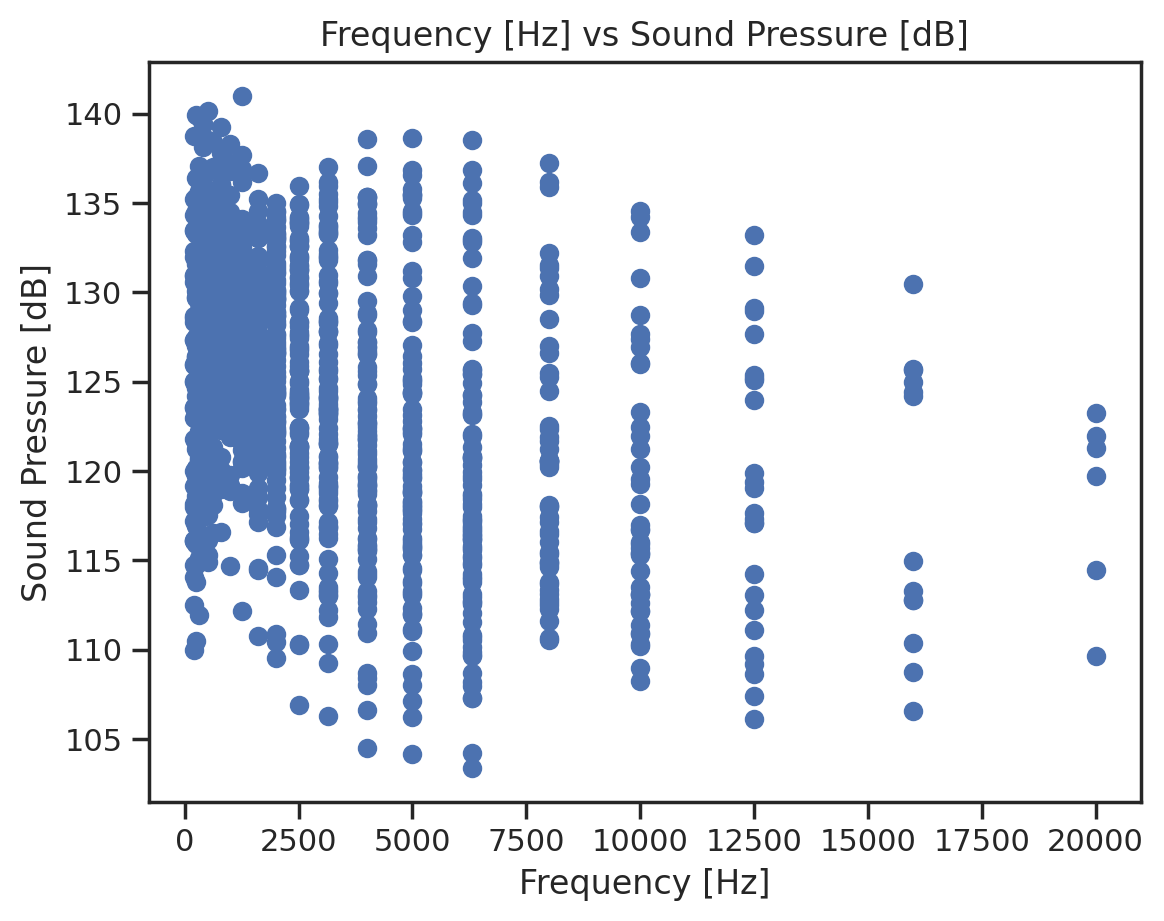

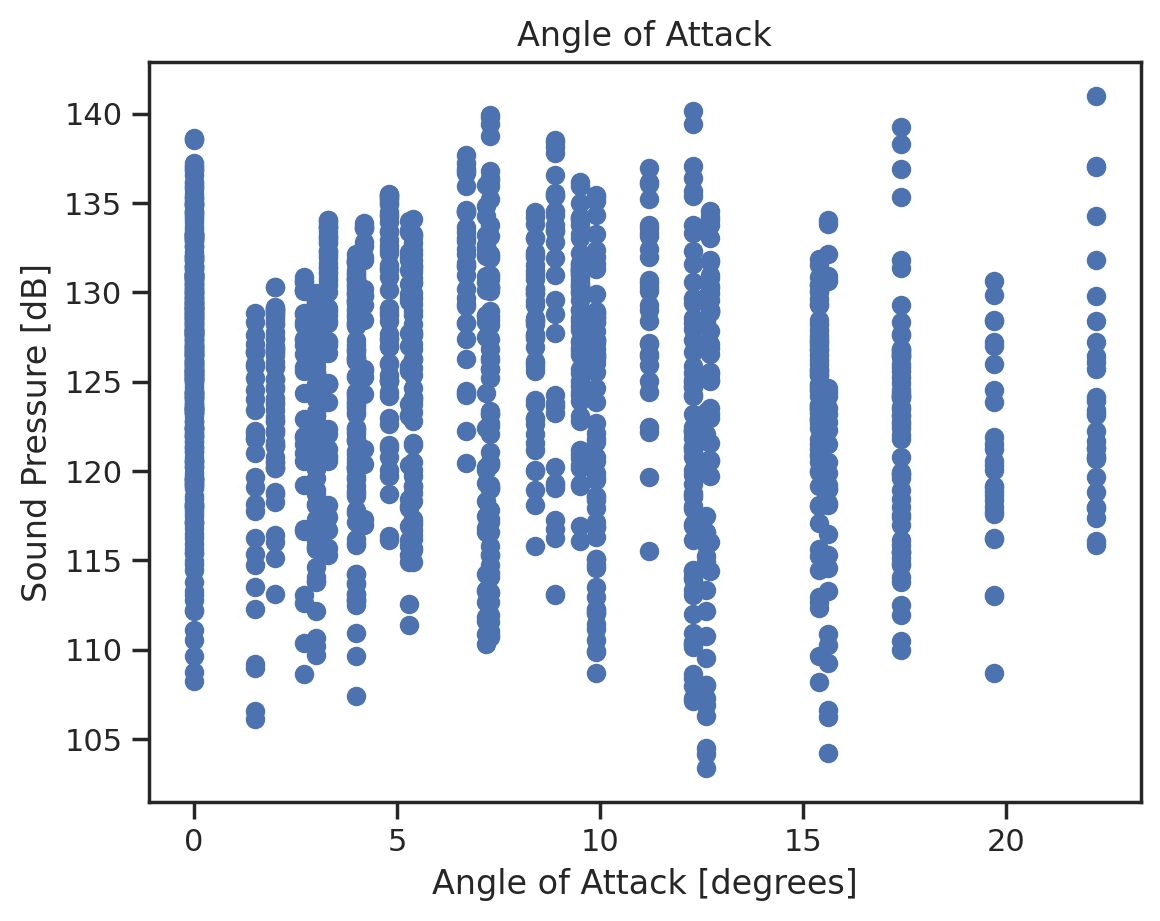

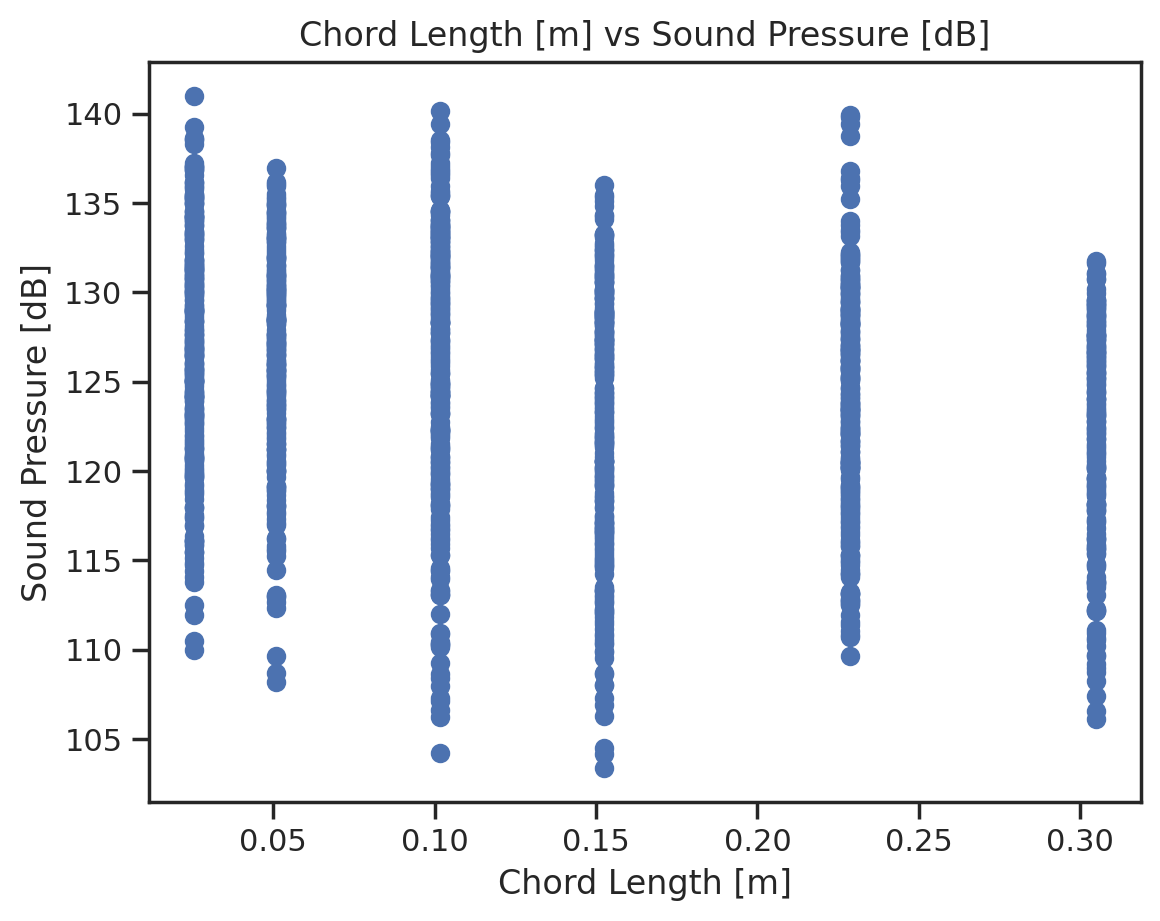

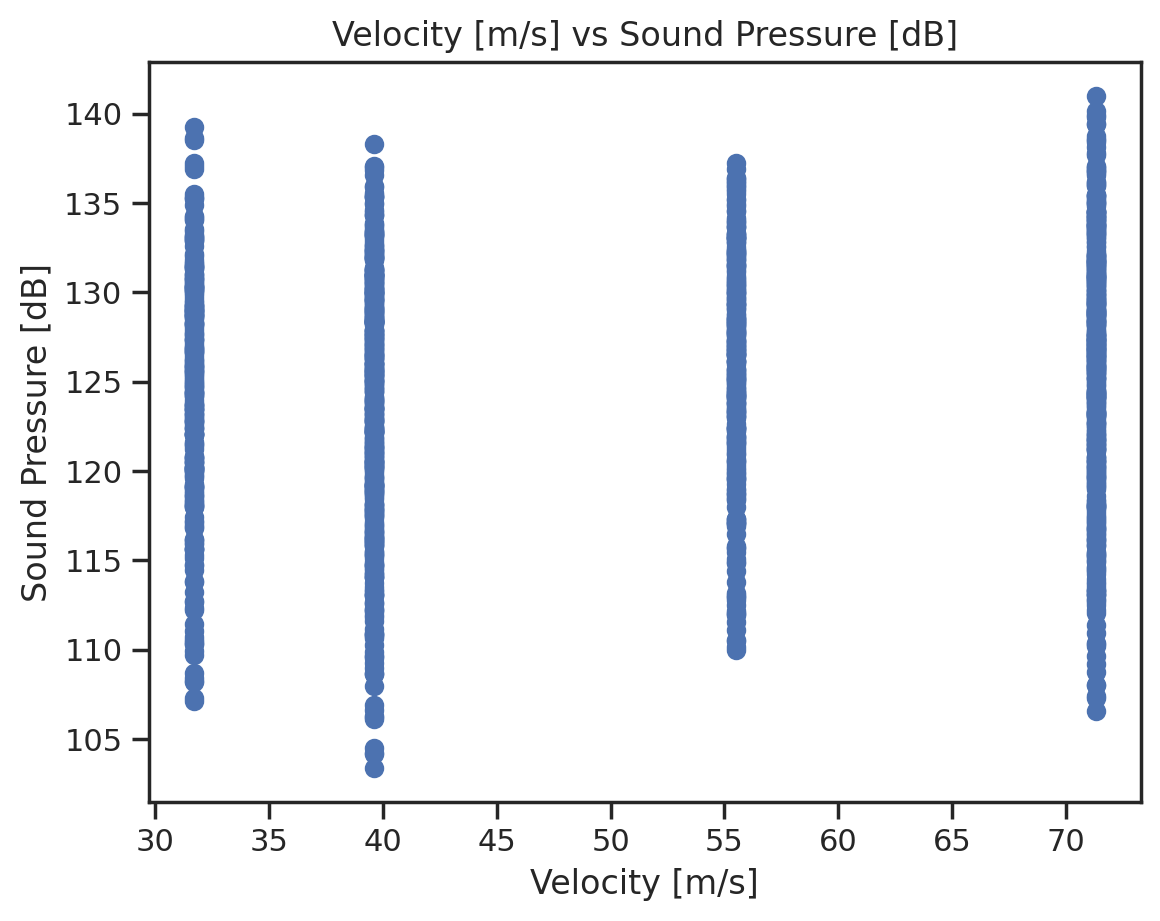

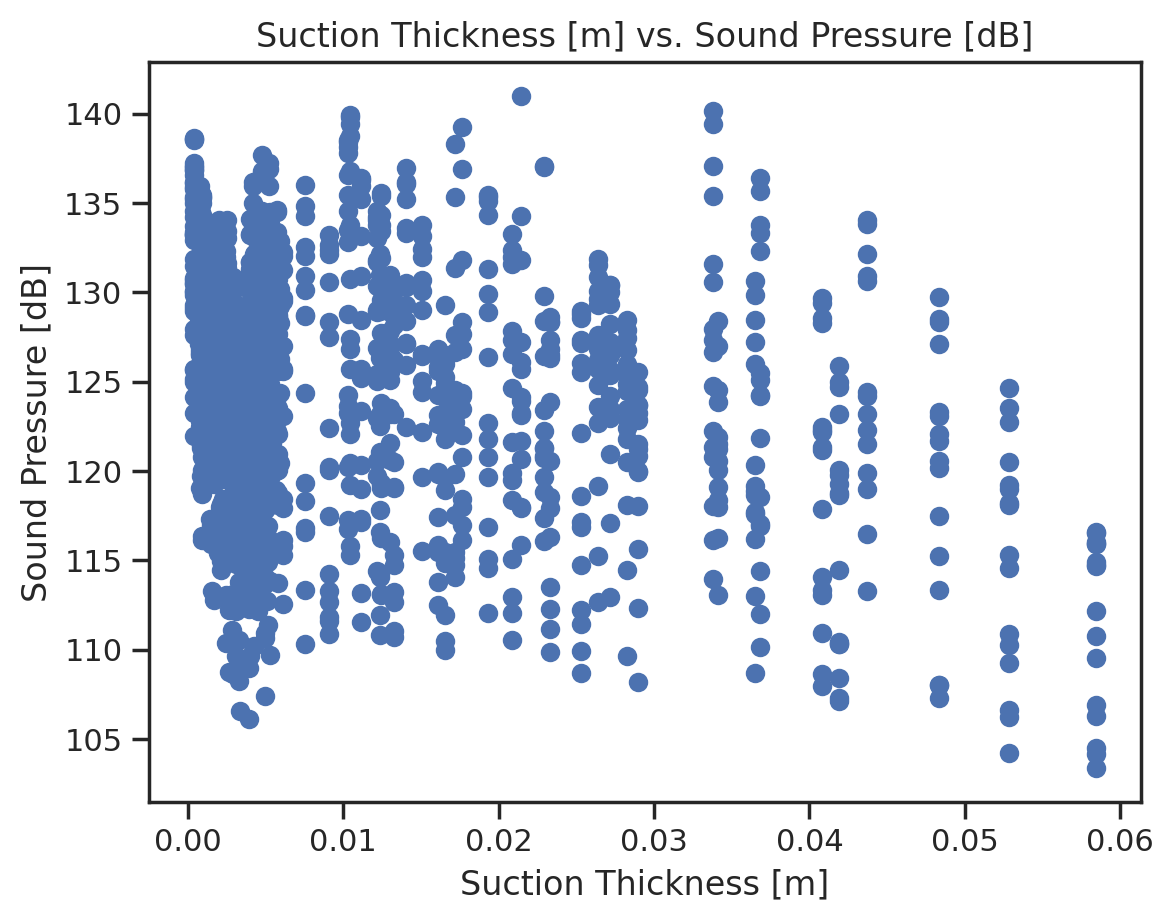

In [ ]:
# your code here (as many blocks as you like)

plt.scatter(df['Frequency'], df['Sound_pressure'])
plt.title('Frequency [Hz] vs Sound Pressure [dB]')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Pressure [dB]')
plt.show()

plt.scatter(df['Angle_of_attack'], df['Sound_pressure'])
plt.title('Angle of Attack')
plt.xlabel('Angle of Attack [degrees]')
plt.ylabel('Sound Pressure [dB]')
plt.show()

plt.scatter(df['Chord_length'], df['Sound_pressure'])
plt.title('Chord Length [m] vs Sound Pressure [dB]')
plt.xlabel('Chord Length [m]')
plt.ylabel('Sound Pressure [dB]')
plt.show()

plt.scatter(df['Velocity'], df['Sound_pressure'])
plt.title('Velocity [m/s] vs Sound Pressure [dB]')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Sound Pressure [dB]')
plt.show()

plt.scatter(df['Suction_thickness'], df['Sound_pressure'])
plt.title('Suction Thickness [m] vs. Sound Pressure [dB]')
plt.xlabel('Suction Thickness [m]')
plt.ylabel('Sound Pressure [dB]')
plt.show()


The evident pattern is that as velocity increases, so does sound pressure. Through the scatter plots, this was the clearest positive correlation. Another relationship that arose was that as suction thickness increases, the sound pressure decreases. Lastly, but one of the weaker correlations between each other was between frequency and sound pressure. As frequency increased there was a weak trend downwards in the sound pressure.

+ Now pick the two input variables you think are the most important and do the scatter plot between them using the output to color the points (see the last question of Problem 1). Feel free to repeat it with more than two pairs of inputs if you want. Briefly discuss your findings.

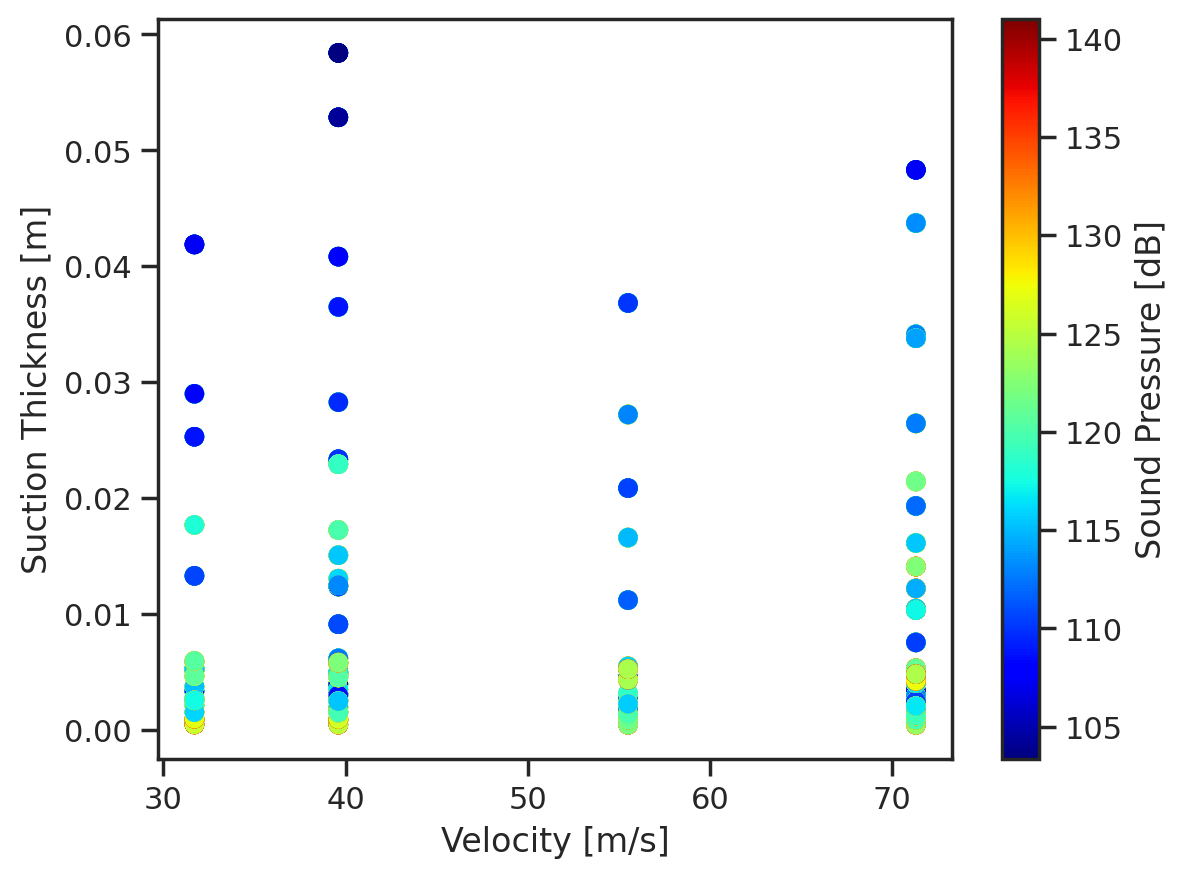

In [ ]:
# your code here (as many blocks as you like)

from matplotlib import cm

fig, ax = plt.subplots()
cs = ax.scatter(df['Velocity'], df['Suction_thickness'], # So far a standard scatter plot
                c=df['Sound_pressure'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Sound Pressure [dB]')   # This gives us a colorbar
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Suction Thickness [m]');

Observing the color map between the suction thickness & velocity versus the sound pressure the graph showed that suction thickness seemed to have the greater impact on the sound pressure as compared to the velocity. This was observed as at the points with equal velocity, as the suction thickness increased the sound pressure decreases. Conversely, holding the suction thickness constant and increasing the velocity resulted in higher sound pressures. This may be due to the higher velocities causing more turbulence in the air, and thus more noise. The higher suction thickness correlating towards a lower sound pressure may be due to some sort of insulating barrier being present due to the suction thickness.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get update --quiet
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy_of_homework_04.ipynb'